#### Modelo baseado em Ilhas
- Topologia Anel

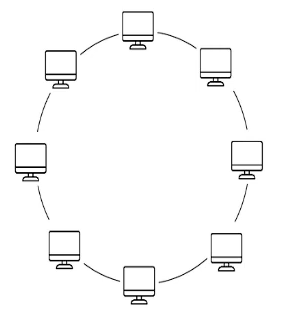


#### Técnicas de implementação
* Técnica de Migração: migRing (Framework DEAP)

#### Programação concorrente
* SCOOP: (https://scoop.readthedocs.io/en/0.7/)

In [1]:
import array
import random
import numpy

from deap import algorithms
from deap import base
from deap import creator
from deap import tools

# Bibliteca execução paralelismo
from scoop import futures

In [2]:
def fitnessFunction(chromosome):
    return sum(chromosome),

In [3]:
# Cria o tipo de função fitness e indivíduo
creator.create("Maximization", base.Fitness, weights=(1.0,))
creator.create("Genes", list,fitness=creator.Maximization)

toolbox = base.Toolbox()
# Registra os nomes e os tipos de individuo, fiteness e população
toolbox.register("Atributo", random.randint, 0, 1)
toolbox.register("Cromossomo", tools.initRepeat, creator.Genes, toolbox.Atributo, n=300 )
toolbox.register("Populacao", tools.initRepeat, list, toolbox.Cromossomo)

# Registra os operadores. Deve-se manter os nomes evaluate, mate, mutate e select
toolbox.register("evaluate", fitnessFunction)
toolbox.register("mate", tools.cxTwoPoint)
toolbox.register("mutate", tools.mutFlipBit, indpb = 0.01)
toolbox.register("select", tools.selTournament, tournsize = 5)

In [4]:
# Registra a execução em paralismo
toolbox.register("map", futures.map)

In [5]:
# Parâmetros do Algoritmo
prob_cx = 0.8
prob_mt = 0.1
nger = 400
freq = 10
tamPop = 30
nIlhas = 5

In [6]:
# Faz a execução do AG em Ilhas
islands = [toolbox.Populacao(n=tamPop) for _ in range(nIlhas)]
toolbox.register("algorithm", algorithms.eaSimple, toolbox=toolbox,cxpb=prob_cx,
                 mutpb = prob_mt, ngen=freq, verbose=False)

for _ in range(0, nger, freq):
  results = toolbox.map(toolbox.algorithm, islands)
  islands = [pop for pop, logbook in results]
  tools.migRing(islands, 5, tools.selBest)

c:\AI\postgrad-ai\.venv\Lib\site-packages\scoop\fallbacks.py:38: RuntimeWarning: SCOOP was not started properly.
Be sure to start your program with the '-m scoop' parameter. You can find further information in the documentation.
Your map call has been replaced by the builtin serial Python map().
  warnings.warn(


In [7]:
# Imprime o fitness máximo e médio por Ilhas
for pop in islands:
  # Armazena o Fitness final de cada Ilha
  finalFitness = []
  for individual in pop:
    finalFitness.append(individual.fitness.values)
  print(f'Max Fitness: {max(finalFitness)} - Avg Fitness: {numpy.mean(finalFitness)}')

Max Fitness: (300.0,) - Avg Fitness: 299.93333333333334
Max Fitness: (300.0,) - Avg Fitness: 299.8
Max Fitness: (300.0,) - Avg Fitness: 299.8
Max Fitness: (300.0,) - Avg Fitness: 299.93333333333334
Max Fitness: (300.0,) - Avg Fitness: 299.73333333333335
